# P-wave-earthquake-localisation-toy-box exemple notebook

In [1]:
import numpy as np

In [2]:
import generate_eq
import graphics
import commons

In [3]:
import Gauss_Newton
import Levenberg_Marquardt
import Uniq_searcher
import deepening_grid

In [4]:

# Deffine the stations, world box and V-P
#                        X       Y     Z    t
stations = np.array([[   0.0,  700.0,  0.0, 0.0],  # N°1
                     [ 700.0, 1000.0,  0.0, 0.0],  # N°2
                     [1000.0,  300.0,  0.0, 0.0],  # N°3
                     [ 500.0,  500.0, 10.0, 0.0],  # N°4
                     [ 400.0,    0.0,  0.0, 0.0]]) # N°5

box_gen = np.array([[    0.0,  1000.0],
                    [    0.0,  1000.0],
                    [-1000.0,     0.0]])

vp = 4000.0 # m/s

# Generate a random event without any noise
event, event_arr, stations, stations_true = generate_eq.generate_event(stations, box_gen, vp, 0.0)
print(f'Event before normalisation:\n\t{event}\n')

# Normalise the stations
stations_norm, event_norm = commons.centrering_arr(stations, event_arr)
event_norm_dict = {'X':float(event_norm[0]), 'Y':float(event_norm[1]),
                   'Z':float(event_norm[2]), 't':float(event_norm[3])}

print(f'Event after normalisation:\n\t{event_norm_dict}\n')

# Compute the normalised world box
limites = np.column_stack((np.min(stations_norm, axis=0), np.max(stations_norm, axis=0)))
limites[2, 0] = -1000

# Set the initialisation to be the same for all iterative solver
event_ini = np.random.rand(4)
event_ini = limites[:, 0] + event_ini * (limites[:, 1]-limites[:, 0])
event_ini[2] = min(event_ini[2], -1)
event_ini_dict = {'X':float(event_ini[0]), 'Y':float(event_ini[1]),
                  'Z':float(event_ini[2]), 't':float(event_ini[3])}

print(f'Initialisation:\n\t{event_ini_dict}\n')


Event before normalisation:
	{'X': 651.8840117423084, 'Y': 869.9917781618782, 'Z': -314.88465324644005, 't': 1785272581.6993308}

Event after normalisation:
	{'X': 151.88401174230842, 'Y': 369.9917781618782, 'Z': -324.88465324644005, 't': -0.12881970405578613}

Initialisation:
	{'X': -27.431483109134774, 'Y': 318.8794695454785, 'Z': -56.47391836162444, 't': 0.08358806048246989}



Best fitt with:
	- RMSE = 3.786049862698166e-08
	- Event = {'X': 151.8834078651255, 'Y': 369.99147933434693, 'Z': -324.8833913285578, 't': -0.12881953752933564}


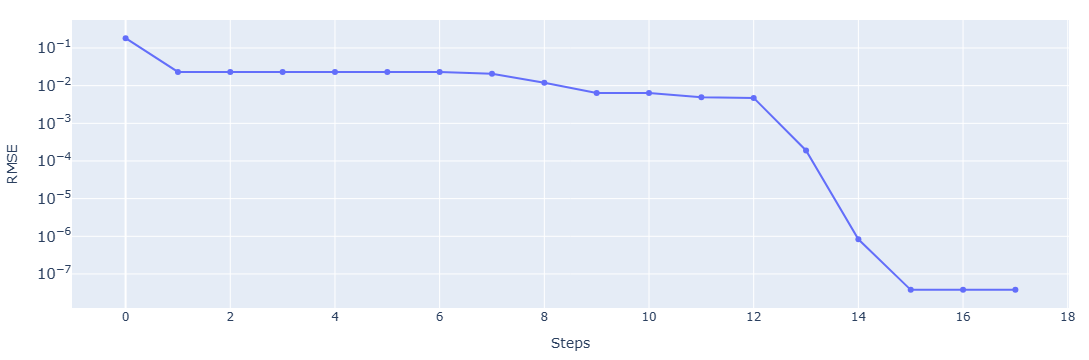

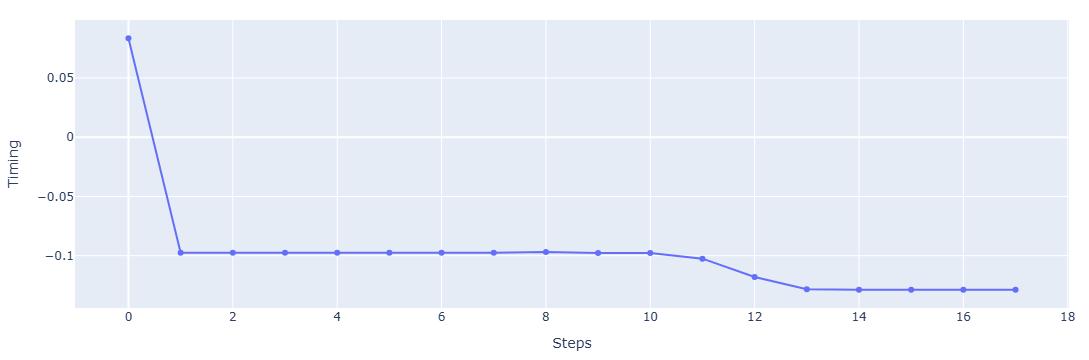

In [5]:
event_best_GN, history_GN, cost_story_GN, misfit_fin_GN = Gauss_Newton.Gauss_Newton(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    steps=np.array([1.0, 1.0, 1.0, 0.0005]),
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_GN}')
print(f'\t- Event = {event_best_GN}')

_ = graphics.history_2d(cost_story_GN, 'RMSE', log_y=True)
_ = graphics.history_2d(history_GN[:, 3], 'Timing')
_ = graphics.history_3d(history_GN[:, :3], stations_norm)

Best fitt with:
	- RMSE = 3.786049862697607e-08
	- Event = {'X': 151.8834078651255, 'Y': 369.99147933434676, 'Z': -324.88339132855725, 't': -0.12881953752933556}


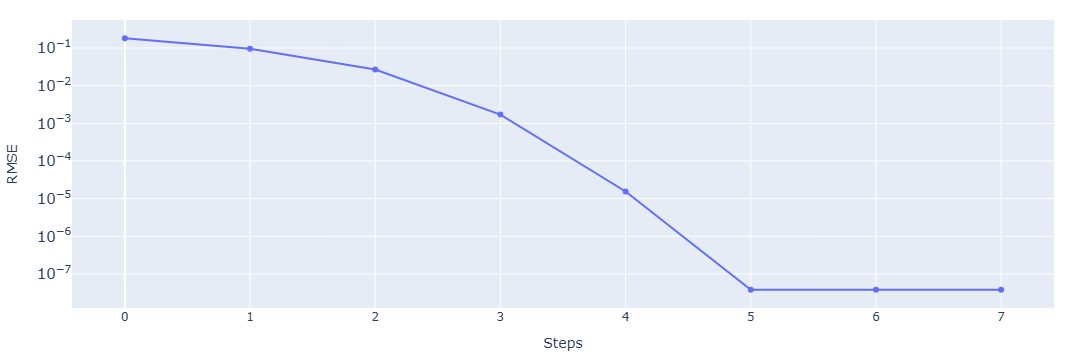

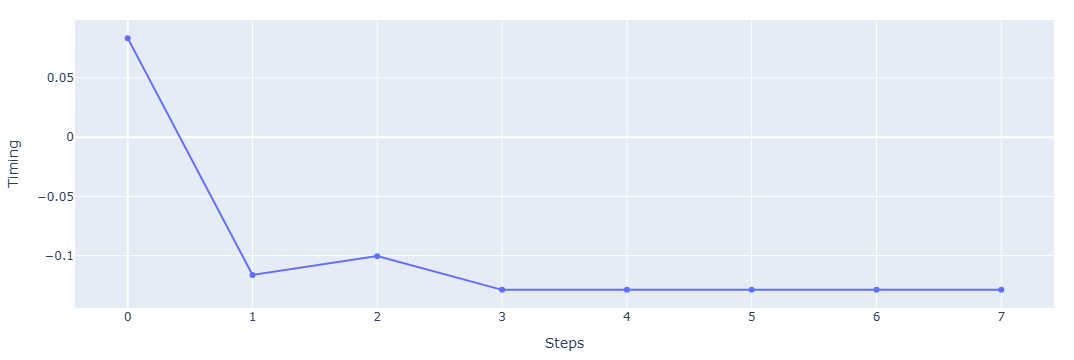

In [6]:
event_best_LM, history_LM, cost_story_LM, misfit_fin_LM = Levenberg_Marquardt.Levenberg_Marquardt(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_LM}')
print(f'\t- Event = {event_best_LM}')

_ = graphics.history_2d(cost_story_LM, 'RMSE', log_y=True)
_ = graphics.history_2d(history_LM[:, 3], 'Timing')
_ = graphics.history_3d(history_LM[:, :3], stations_norm)

Best fitt with:
	- RMSE = 3.786049953944934e-08
	- Event = {'X': 151.8834078185007, 'Y': 369.9914792183868, 'Z': -324.8833910298516, 't': -0.12881953747380173}


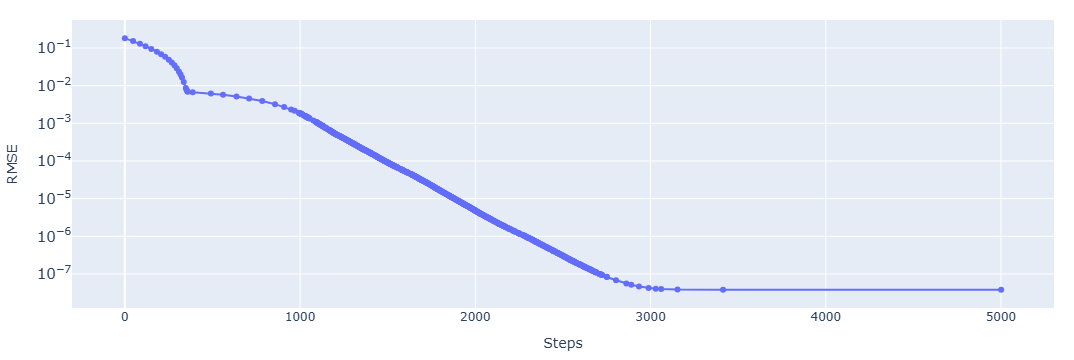

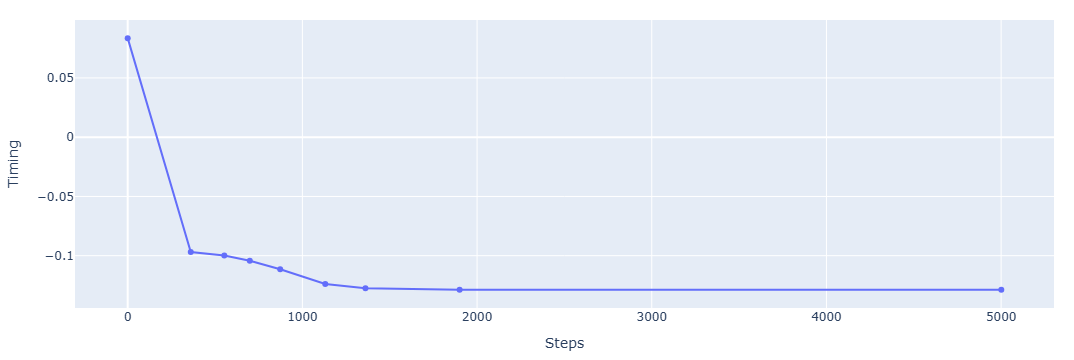

In [7]:
event_best_US, history_US, cost_story_US, misfit_fin_US = Uniq_searcher.gradient_descent(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=200_000,
    ranX=1,
    ranY=1,
    ranZ=1,
    rant=0.0005,
    lr_decay=0.05,
    patience=500,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_US}')
print(f'\t- Event = {event_best_US}')

_ = graphics.history_2d(cost_story_US, 'RMSE', log_y=True)
_ = graphics.history_2d(history_US[:, 3], 'Timing')
_ = graphics.history_3d(history_US[:, :3], stations_norm)

Best fitt with:
	- RMSE = 3.798276683534999e-08
	- Event = {'X': 151.8833770751953, 'Y': 369.991455078125, 'Z': -324.8833312988281, 't': -0.1288195252418518}


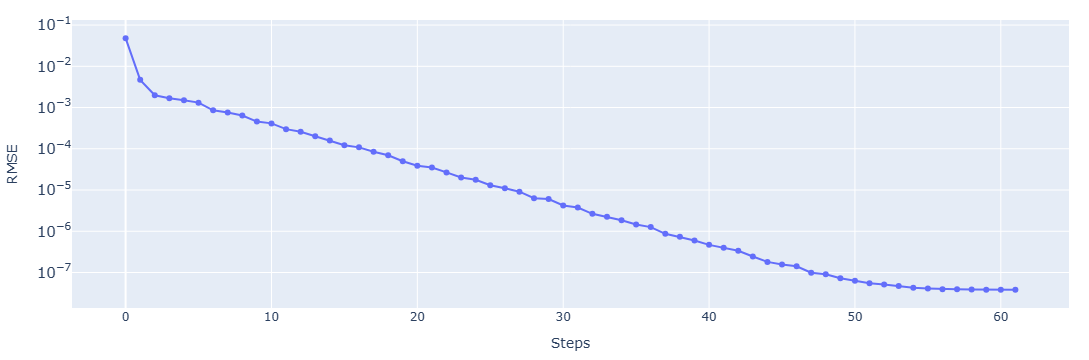

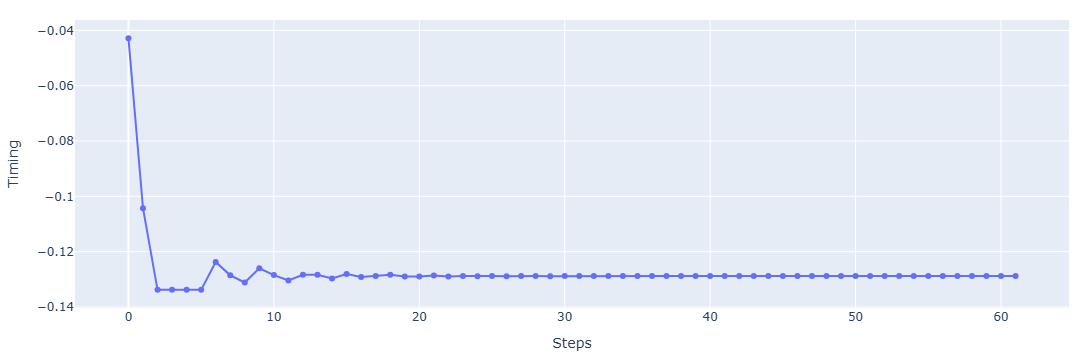

In [8]:
event_best_DG, history_DG, cost_story_DG, misfit_fin_DG = deepening_grid.deepening_grid_search(
    stations=stations_norm,
    sampling_f=21,
    limites=np.copy(limites),
    depth=1001,
    halving_rate=0.20,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DG}')
print(f'\t- Event = {event_best_DG}')

_ = graphics.history_2d(cost_story_DG, 'RMSE', log_y=True)
_ = graphics.history_2d(history_DG[:, 3], 'Timing')
_ = graphics.history_3d(history_DG[:, :3], stations_norm)

In [9]:
event_best_DGS, history_DGS, cost_story_DGS, misfit_fin_DGS = deepening_grid.deepening_grid_sampling(
    stations=stations_norm,
    sampling_f=6,
    limites=np.copy(limites),
    depth=1001,
    halving_rate=0.20,
    n_samples=100,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DGS}')
print(f'\t- Event = {event_best_DGS}')

_ = graphics.history_2d(cost_story_DGS, 'RMSE', log_y=True)
_ = graphics.history_2d(history_DGS[:, 3], 'Timing')
_ = graphics.history_3d(history_DGS[:, :3], stations_norm)

Best fitt with:
	- RMSE = 3.904612816562634e-08
	- Event = {'X': 151.88345336914062, 'Y': 369.991455078125, 'Z': -324.8832702636719, 't': -0.1288195252418518}
